# Chapter 60 — Uncertainty, Validation, and Trust in AI-Based Measurement
### *Modern Strain Gage Technology* — Companion Notebook

**Companion notebook to Chapter 60 — Uncertainty, Validation, and Trust in AI-Based Measurement.**

A machine learning model produces a number; it does not, by default, produce a number with a stated uncertainty — and until it does, that number is not yet a *measurement* in the metrological sense.

This asymmetry is critical for safety-critical structural sensing: an analyst relying on a model-based load estimate needs to know not just the value but how much to trust it. Without quantified uncertainty, the model output is not a measurement — it is an assertion.

Four methods for quantifying ML uncertainty are increasingly deployed in structural health monitoring. **Bootstrap resampling** trains many models on slightly different data and treats the spread of their predictions as an estimate of *epistemic* uncertainty. **Calibration** checks whether stated confidence levels match observed coverage — a model claiming 95% intervals but achieving only 70% coverage is dangerously overconfident. **Out-of-distribution detection** asks whether the current input resembles the training data; a model operating beyond its training domain is unreliable regardless of what its stated interval says. **Conformal prediction** bypasses distributional assumptions by constructing intervals with finite-sample coverage guarantees, requiring no assumptions about the model or the error distribution.

The failure modes matter as much as the methods. Bootstrap uncertainty cannot be trusted in extrapolation regimes — the model has no mechanism to recognize that it is operating beyond its training distribution. Calibration checks are retrospective diagnostics, not prospective guarantees. Conformal prediction provides the strongest guarantee but produces marginal intervals that do not adapt to local uncertainty structure.

**This notebook demonstrates:**
1. **Bootstrap uncertainty** — confidence intervals from ensemble variance, with coverage calibration against a reliability diagram.
2. **Calibration** — overconfident, well-calibrated, and underconfident interval models visualized on a reliability diagram and a CI-width scatter plot. This is where we make the *confidence interval vs. prediction interval* distinction from the chapter concrete.
3. **Out-of-distribution extrapolation** — a model trained on the elastic regime that is confidently wrong in the post-yield regime.
4. **Conformal prediction** — distribution-free, coverage-guaranteed intervals vs. bootstrap, with printed coverage and interval-width comparison.

In [1]:
# !pip install numpy matplotlib scikit-learn
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Figures land in the folder the book's \includegraphics{} calls expect.
OUT_DIR = Path("../src/media/ch60")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Shared constants ─────────────────────────────────────────────────────────
N_ESTIMATORS = 120     # trees per gradient-boosted regressor
GAGE_LIN     = 1.8     # N per µε   — linear load–strain coefficient (synthetic law)
GAGE_QUAD    = 0.0002  # N per µε²  — quadratic stiffening term (synthetic law)
Z_95         = 1.96    # two-sided Gaussian multiplier for a 95% interval

# In-distribution data-generating parameters, shared by §1 (bootstrap) and
# §4 (conformal). §3 (OOD) deliberately uses a narrower range and its own noise.
STRAIN_MAX   = 3000    # µε — strain range for the in-distribution datasets
NOISE_STD    = 250     # N  — irreducible (aleatoric) measurement noise

# Standard two-sided Gaussian z-multipliers for a few central confidence levels.
CONF_TABLE = {0.50: 0.674, 0.80: 1.282, 0.90: 1.645, 0.95: 1.960, 0.99: 2.576}

### Shared helpers

Three small, reusable pieces used throughout: a synthetic load–strain law, a bootstrap ensemble, and a lookup for Gaussian confidence multipliers. Keeping them in one place (with fixed seeds) is what makes every figure below reproducible — rerun the notebook top-to-bottom and you get the same numbers.

In [2]:
def simulate_load(eps, noise_std):
    """Synthetic load–strain law: linear + quadratic stiffening + Gaussian noise.

    Parameters
    ----------
    eps : ndarray
        Strain values in µε.
    noise_std : float
        Standard deviation (N) of the irreducible measurement noise. This is
        the *aleatoric* term — the part no model can learn away.

    Returns
    -------
    ndarray
        Simulated load in N. Consumes the global NumPy RNG for the noise draw,
        so seed before calling for reproducibility.
    """
    return GAGE_LIN * eps + GAGE_QUAD * eps**2 + np.random.normal(0, noise_std, size=len(eps))


def bootstrap_predict(X_train, y_train, X_eval, n_boot, n_estimators=N_ESTIMATORS):
    """Train an ensemble of gradient-boosted regressors on bootstrap resamples.

    Draws ``n_boot`` samples (with replacement) from the training set, fits a
    ``GradientBoostingRegressor`` to each (seeded by its index), and stacks the
    predictions at ``X_eval``. The column mean is the point estimate; the column
    standard deviation estimates *epistemic* (model) uncertainty — the spread
    that comes from not having seen enough data. It does NOT include the
    aleatoric noise, a distinction that drives the calibration section below.

    Parameters
    ----------
    X_train, y_train : ndarray
        Training features (2-D, shape ``(n, 1)``) and targets.
    X_eval : ndarray
        Points to predict at (2-D).
    n_boot : int
        Number of bootstrap models.
    n_estimators : int
        Trees per gradient-boosted model.

    Returns
    -------
    ndarray
        Shape ``(n_boot, len(X_eval))`` — one prediction row per bootstrap model.
    """
    preds = np.zeros((n_boot, len(X_eval)))
    for i in range(n_boot):
        idx = np.random.choice(len(X_train), len(X_train), replace=True)
        model = GradientBoostingRegressor(n_estimators=n_estimators, random_state=i)
        model.fit(X_train[idx], y_train[idx])
        preds[i] = model.predict(X_eval)
    return preds


def z_for_confidence(conf_level):
    """Two-sided Gaussian z-multiplier for a central confidence level.

    E.g. ``z_for_confidence(0.95) -> 1.96``. Linearly interpolated from the
    small standard table ``CONF_TABLE`` so a smooth reliability curve can be
    swept across confidence levels.
    """
    return np.interp(conf_level, list(CONF_TABLE), list(CONF_TABLE.values()))

---
## 1 — Bootstrap Uncertainty

A single trained model produces a single prediction. It has no natural way to say *how confident* it is. **Bootstrap resampling** fixes that by training many models on slightly different draws from the same data, then treating the spread of their predictions as a proxy for **epistemic uncertainty** — the part of the uncertainty that comes from not having seen enough data, as opposed to the irreducible measurement noise.

**How it works:** draw *B* bootstrap samples (with replacement) from the training set, fit a separate model to each, and collect the *B* predictions at every test point. The mean of those predictions is the point estimate; the standard deviation is the uncertainty. Multiplying by a z-score (1.96 for 95%, 1.282 for 80%) gives a confidence interval.

The right panel checks whether those intervals are actually honest: plot the stated confidence level against the fraction of test points that truly fall inside the interval at that level. A perfectly calibrated model sits exactly on the diagonal.

Watch what happens here: the observed coverage lands *well below* the diagonal. That is not a bug — it is the whole lesson. The bootstrap spread measures only how much the *model's mean* wobbles; it says nothing about the measurement noise scattered around that mean. So this is a **confidence interval on the mean**, and it systematically undercovers actual observations. Section 2 repairs it by folding the noise back in to build an honest **prediction interval** — the chapter's confidence-interval-vs-prediction-interval distinction, made numerical.

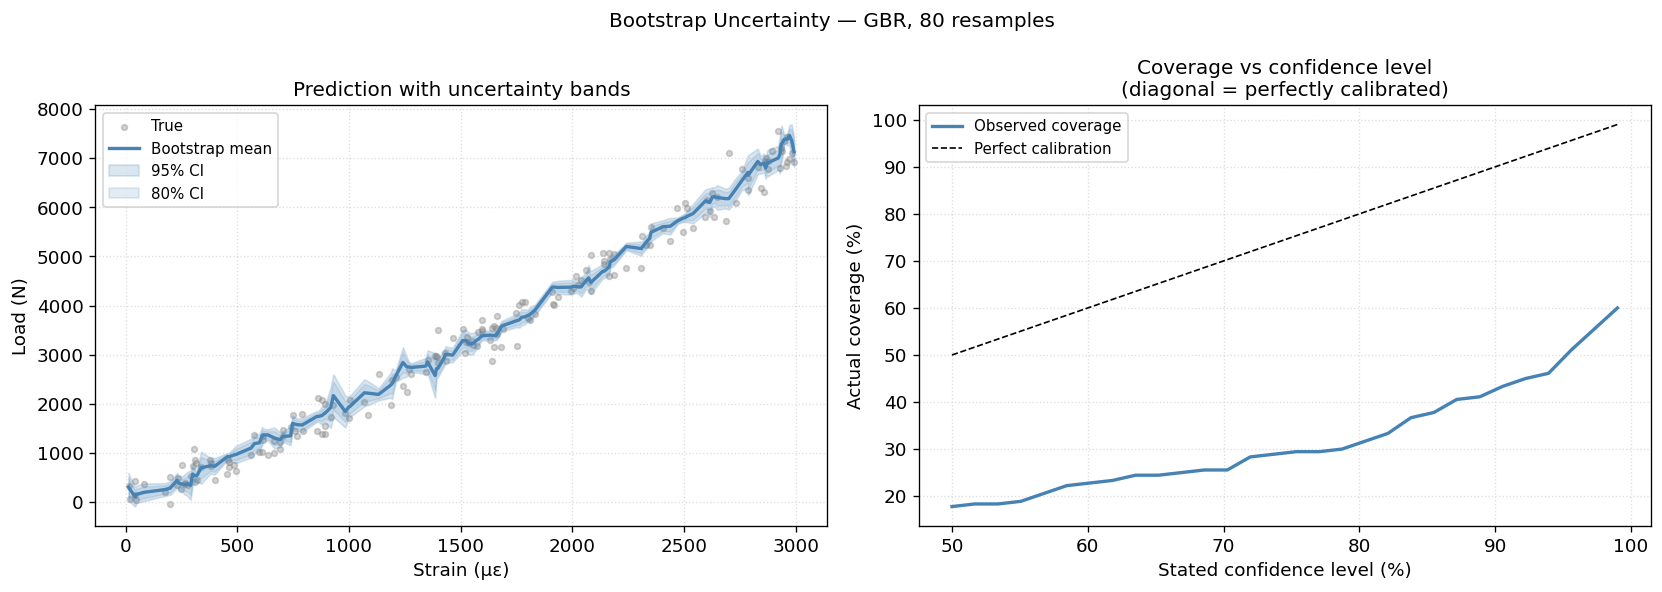

R² = 0.9853
95% CI actual coverage: 46.7%
→ Coverage far below 95%: the ensemble spread captures model (epistemic)
  uncertainty only, not the measurement noise. This is an overconfident
  *confidence* interval on the mean — Section 2 turns it into an honest
  *prediction* interval.


In [3]:
# ── 1. Bootstrap Uncertainty ─────────────────────────────────────────────────
np.random.seed(99)

N_POINTS = 600     # in-distribution samples (STRAIN_MAX, NOISE_STD from setup cell)
N_BOOT   = 80      # bootstrap ensemble size

eps  = np.random.uniform(0, STRAIN_MAX, N_POINTS)
load = simulate_load(eps, NOISE_STD)
X    = eps.reshape(-1, 1)
y    = load

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

# One prediction row per bootstrap model; column mean/std give estimate + spread.
preds_boot = bootstrap_predict(X_tr, y_tr, X_te, N_BOOT)
y_mean = preds_boot.mean(axis=0)
y_std  = preds_boot.std(axis=0)   # epistemic uncertainty only (no aleatoric noise)

# Sweep the stated confidence level and record the coverage actually achieved.
conf_levels = np.linspace(0.50, 0.99, 30)
coverages   = []
for cl in conf_levels:
    z   = z_for_confidence(cl)
    cov = np.mean((y_te >= y_mean - z*y_std) & (y_te <= y_mean + z*y_std))
    coverages.append(cov)

sort_idx = np.argsort(X_te[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bootstrap Uncertainty — GBR, 80 resamples', fontsize=12)

ax = axes[0]
ax.scatter(X_te[sort_idx, 0], y_te[sort_idx], s=12, alpha=0.35, color='gray', label='True')
ax.plot(X_te[sort_idx, 0], y_mean[sort_idx], 'steelblue', lw=2, label='Bootstrap mean')
for z, alpha, label in [(1.960, 0.20, '95% CI'), (1.282, 0.15, '80% CI')]:
    ax.fill_between(X_te[sort_idx, 0],
                    y_mean[sort_idx] - z*y_std[sort_idx],
                    y_mean[sort_idx] + z*y_std[sort_idx],
                    alpha=alpha, color='steelblue', label=label)
ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Load (N)')
ax.set_title('Prediction with uncertainty bands')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

ax = axes[1]
ax.plot(conf_levels*100, np.array(coverages)*100, 'steelblue', lw=2, label='Observed coverage')
ax.plot([50, 99], [50, 99], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Stated confidence level (%)')
ax.set_ylabel('Actual coverage (%)')
ax.set_title('Coverage vs confidence level\n(diagonal = perfectly calibrated)')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig60_nb1_bootstrap_uncertainty.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"R² = {r2_score(y_te, y_mean):.4f}")
cov_95 = np.mean((y_te >= y_mean - Z_95*y_std) & (y_te <= y_mean + Z_95*y_std))
print(f"95% CI actual coverage: {cov_95*100:.1f}%")
print("→ Coverage far below 95%: the ensemble spread captures model (epistemic)")
print("  uncertainty only, not the measurement noise. This is an overconfident")
print("  *confidence* interval on the mean — Section 2 turns it into an honest")
print("  *prediction* interval.")

---
## 2 — Calibration

Producing a confidence interval is easy. Producing an *honest* one is hard.

A model is **well-calibrated** if its stated 80% interval actually contains the true value 80% of the time — not 60%, not 95%. The **reliability diagram** (left panel) makes calibration visible: plot stated confidence on the x-axis, observed coverage on the y-axis. A curve that hugs the diagonal is calibrated. A curve that bows *below* it is **overconfident** — the intervals are too narrow and the model is more certain than it should be. A curve that bows *above* it is **underconfident** — intervals are wider than necessary.

Section 1 left us with exactly the overconfident case, and it told us why: the bootstrap standard deviation captures only **epistemic** (model) uncertainty and omits the **aleatoric** measurement noise. To build an honest interval we have to put the noise back. We estimate it directly from the data using the *law of total variance* — the variance of the residuals splits into an epistemic part (the mean bootstrap variance we already have) and an aleatoric remainder:

$$\underbrace{\operatorname{Var}(y - \hat{y})}_{\text{total residual}} \;=\; \underbrace{\overline{\sigma_{\text{epi}}^2}}_{\text{model spread}} \;+\; \underbrace{\sigma_{\text{ale}}^2}_{\text{noise}}$$

In words: subtract the epistemic variance the ensemble already reports from the total scatter of the residuals, and what remains is an estimate of the irreducible noise variance. Adding the two back together gives a **prediction-interval** standard deviation, $\sigma_{\text{pred}} = \sqrt{\sigma_{\text{epi}}^2 + \sigma_{\text{ale}}^2}$, that should land on the diagonal.

This cell builds three honest variants from that decomposition: **overconfident** (epistemic std only — the Section 1 interval), **well-calibrated** (the full predictive std), and **underconfident** (the predictive std inflated 2×). The right panel shows the same three as raw 95% interval widths across the strain range, so overconfidence is visible as physically narrower bands, not just an abstract curve.

**Why overconfidence is the dangerous direction:** an overconfident SHM model reports a tight interval around an incorrect load estimate, giving an engineer false assurance that the reading is reliable.

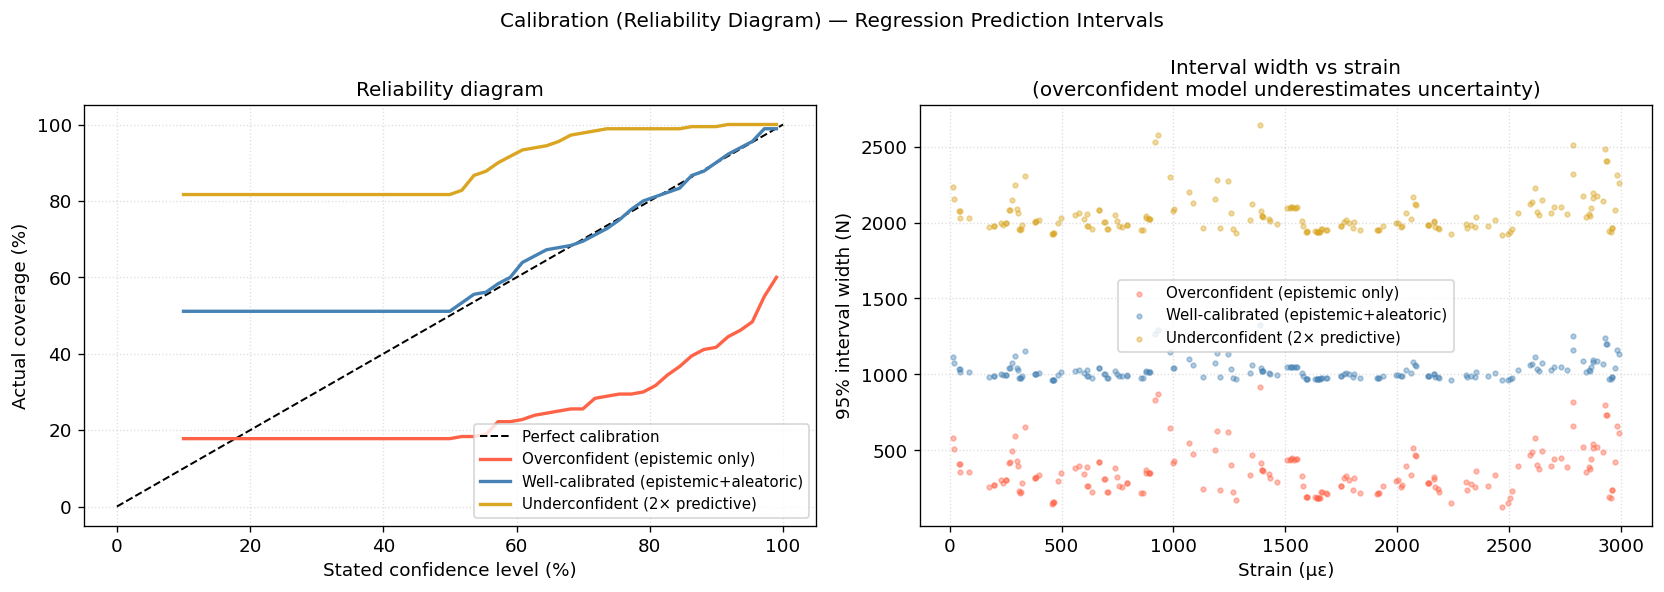

Estimated aleatoric noise std: 243 N (true value used to generate data: 250 N)
  Overconfident (epistemic only)           95% coverage =  46.7%
  Well-calibrated (epistemic+aleatoric)    95% coverage =  94.4%
  Underconfident (2× predictive)           95% coverage = 100.0%


In [4]:
# ── 2. Calibration — Reliability Diagram ─────────────────────────────────────
# The Section-1 bootstrap std (y_std) is epistemic ONLY, so its intervals
# undercover. We recover the aleatoric noise via the law of total variance and
# add it back to form an honest prediction-interval std. Then we compare three
# variants: overconfident (epistemic only), well-calibrated (full predictive),
# and underconfident (predictive inflated 2x).

residuals     = y_te - y_mean
total_var     = np.var(residuals)          # total scatter of the residuals
epistemic_var = np.mean(y_std**2)          # mean bootstrap (model) variance
aleatoric_var = max(total_var - epistemic_var, 0.0)   # law of total variance
sigma_pred    = np.sqrt(y_std**2 + aleatoric_var)      # prediction-interval std (per point)

variants = {
    'Overconfident (epistemic only)':      y_std,
    'Well-calibrated (epistemic+aleatoric)': sigma_pred,
    'Underconfident (2× predictive)':      2.0 * sigma_pred,
}
colors = ['tomato', 'steelblue', 'goldenrod']

conf_levels_fine = np.linspace(0.10, 0.99, 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calibration (Reliability Diagram) — Regression Prediction Intervals', fontsize=12)

ax = axes[0]
ax.plot([0, 100], [0, 100], 'k--', lw=1.2, label='Perfect calibration')
for (name, std), color in zip(variants.items(), colors):
    covs = []
    for cl in conf_levels_fine:
        z   = z_for_confidence(cl)
        cov = np.mean((y_te >= y_mean - z*std) & (y_te <= y_mean + z*std))
        covs.append(cov)
    ax.plot(conf_levels_fine*100, np.array(covs)*100, color=color, lw=2, label=name)
ax.set_xlabel('Stated confidence level (%)')
ax.set_ylabel('Actual coverage (%)')
ax.set_title('Reliability diagram')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

# Raw 95% interval width for each variant, across the strain range.
ax = axes[1]
for (name, std), color in zip(variants.items(), colors):
    widths = 2 * Z_95 * std
    ax.scatter(X_te[sort_idx, 0], widths[sort_idx],
               s=8, alpha=0.4, color=color, label=name)
ax.set_xlabel('Strain (µε)')
ax.set_ylabel('95% interval width (N)')
ax.set_title('Interval width vs strain\n(overconfident model underestimates uncertainty)')
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig60_nb1_calibration_reliability.png', bbox_inches='tight', dpi=150)
plt.show()

# Coverage each variant achieves at a nominal 95% level.
print(f"Estimated aleatoric noise std: {np.sqrt(aleatoric_var):.0f} N "
      f"(true value used to generate data: {NOISE_STD} N)")
for name, std in variants.items():
    cov = np.mean((y_te >= y_mean - Z_95*std) & (y_te <= y_mean + Z_95*std))
    print(f"  {name:<40s} 95% coverage = {cov*100:5.1f}%")

---
## 3 — Out-of-Distribution Extrapolation

Of all the ways an ML model can fail in the field, this one causes the most accidents: the model looks confident, the output looks plausible, and no alarm fires — because the model has no mechanism to know it is operating outside the range of data it was trained on.

A gradient-boosted tree trained on 0–2000 µε (elastic regime) will produce a smooth, credible-looking prediction curve when asked to evaluate a 3500 µε input. It has no concept of post-yield softening. Its bootstrap CI reflects only the variance it has seen in-distribution; it has no way to inflate the interval for inputs it has never encountered.

**The setup:** train on the elastic regime only (0–2000 µε), then evaluate across 0–4500 µε. The true physics includes post-yield softening that begins at ~2200 µε — a regime the model has never seen. The shaded red region in both panels marks where the model is extrapolating.

The zoom panel on the right makes the gap unmistakable: the model's CI tracks confidently upward while the true load curve bends downward. The printed summary quantifies whether the CI half-width is larger or smaller than the actual error — the formal test for "confident but wrong."

**Practical implication:** always instrument your deployment data with a feature-space distance or density check to flag inputs that are far from the training distribution, and treat the model's stated uncertainty as unreliable in those regions.

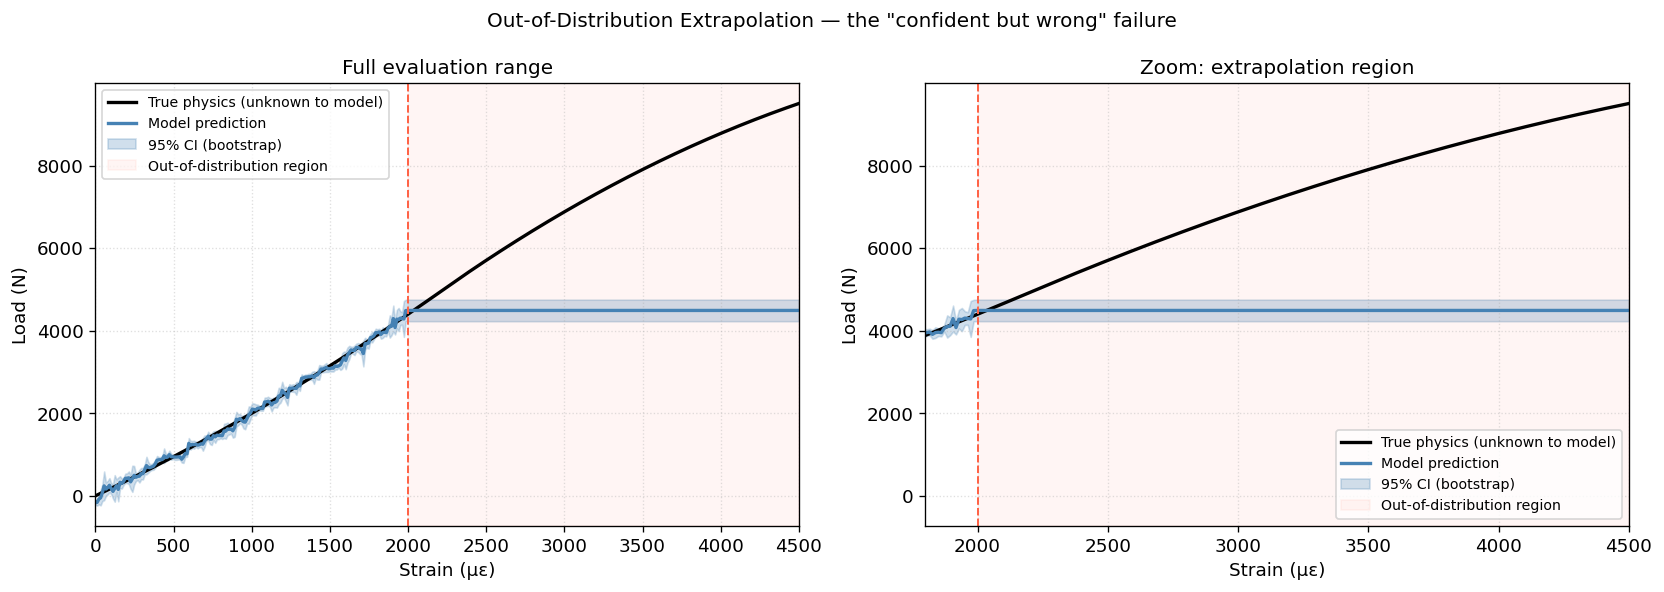

Mean absolute error in OOD region:   2999 N
Mean 95% CI half-width in OOD region: 261 N
Model is overconfident in OOD region


In [5]:
# ── 3. Out-of-Distribution Extrapolation ─────────────────────────────────────
# The most dangerous failure mode: a model trained on one strain range is
# applied to a wider one. Predictions look smooth and confident, but the true
# relationship diverges once we leave the training domain.

np.random.seed(11)

N_TRAIN_OOD  = 500
TRAIN_MAX    = 2000    # µε — model sees only the elastic regime, 0–2000
EVAL_MAX     = 4500    # µε — evaluation extends into post-yield territory
N_EVAL       = 400
YIELD_PT     = 2200    # µε — true post-yield softening begins here
SOFTEN_COEF  = 0.0005  # N per µε² — strength of the post-yield softening
NOISE_STD_OOD = 200    # N
N_BOOT_OOD   = 60

eps_tr  = np.random.uniform(0, TRAIN_MAX, N_TRAIN_OOD)
load_tr = simulate_load(eps_tr, NOISE_STD_OOD)

# True physics across the full range includes post-yield softening the model
# never sees during training.
eps_full = np.linspace(0, EVAL_MAX, N_EVAL)
post     = np.maximum(0, eps_full - YIELD_PT)
load_true_full = GAGE_LIN*eps_full + GAGE_QUAD*eps_full**2 - SOFTEN_COEF*post**2

# Bootstrap ensemble trained ONLY on in-distribution data.
preds_ood = bootstrap_predict(eps_tr.reshape(-1, 1), load_tr,
                              eps_full.reshape(-1, 1), N_BOOT_OOD)
mean_ood = preds_ood.mean(axis=0)
std_ood  = preds_ood.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Out-of-Distribution Extrapolation — the "confident but wrong" failure', fontsize=12)

for ax, xlim, title in [
    (axes[0], (0, EVAL_MAX),        'Full evaluation range'),
    (axes[1], (1800, EVAL_MAX),     'Zoom: extrapolation region'),
]:
    ax.plot(eps_full, load_true_full, 'k-', lw=2, label='True physics (unknown to model)')
    ax.plot(eps_full, mean_ood, 'steelblue', lw=2, label='Model prediction')
    ax.fill_between(eps_full,
                    mean_ood - Z_95*std_ood,
                    mean_ood + Z_95*std_ood,
                    alpha=0.25, color='steelblue', label='95% CI (bootstrap)')
    ax.axvspan(TRAIN_MAX, EVAL_MAX, alpha=0.06, color='tomato', label='Out-of-distribution region')
    ax.axvline(TRAIN_MAX, color='tomato', lw=1.2, ls='--')
    ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Load (N)')
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.legend(fontsize=8.5); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig60_nb1_ood_extrapolation.png', bbox_inches='tight', dpi=150)
plt.show()

# Quantify overconfidence where the true curve has actually diverged (past yield).
ood_mask   = eps_full > YIELD_PT
ood_error  = np.abs(mean_ood[ood_mask] - load_true_full[ood_mask])
ood_halfwidth = (Z_95 * std_ood[ood_mask]).mean()
print(f"Mean absolute error in OOD region:   {ood_error.mean():.0f} N")
print(f"Mean 95% CI half-width in OOD region: {ood_halfwidth:.0f} N")
verdict = 'overconfident' if ood_error.mean() > ood_halfwidth else 'appropriately uncertain'
print(f"Model is {verdict} in OOD region")

---
## 4 — Conformal Prediction

Bootstrap uncertainty and reliability diagrams are diagnostic — they tell you whether your model *happens* to be calibrated on the data you evaluated. They make no guarantee about future data.

**Conformal prediction** (Vovk et al., 2005) flips the problem: instead of hoping the model is calibrated, it *constructs* intervals that are guaranteed to achieve at least (1 − α) coverage on any exchangeable test set, regardless of how good or bad the underlying model is.

The mechanism is elegantly simple — *split conformal prediction*:

| Step | What happens |
|------|-------------|
| 1 | Fit the model on a training split |
| 2 | Run the model on a held-out **calibration** split; record the absolute residuals as *nonconformity scores* |
| 3 | Compute `q̂` = the ⌈(1 − α)(n_cal + 1)⌉ / n_cal quantile of those scores |
| 4 | For any new test point: prediction interval = `ŷ ± q̂` |

The coverage guarantee follows from a finite-sample exchangeability argument — no normality assumption, no model assumptions at all. The only cost is that the intervals are *marginal* (the same width everywhere) rather than *local* (wider where the model is uncertain). More advanced variants (locally-adaptive conformal) relax this.

The printed output compares conformal coverage to bootstrap coverage on identical test data and reports the mean interval width for both — showing whether the coverage guarantee comes at a price in interval efficiency.

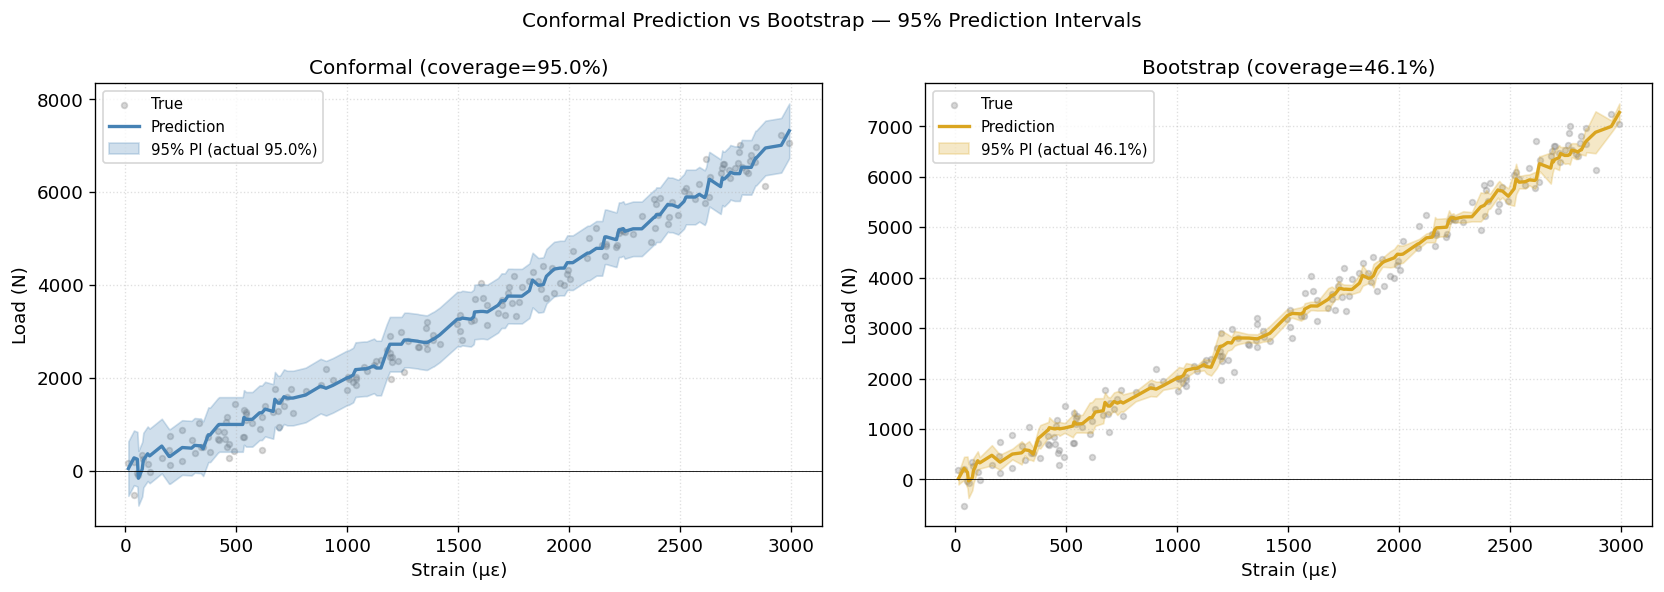

Conformal q̂ (interval half-width): 587.6 N
Conformal coverage:  95.0%  (guaranteed ≥ 95%)
Bootstrap coverage:  46.1%  (epistemic-only, no such guarantee)
Mean interval width — conformal: 1175.2 N  | bootstrap: 332.1 N


In [6]:
# ── 4. Conformal Prediction — Coverage-Guaranteed Intervals ──────────────────
# Split conformal prediction requires no distributional assumptions and
# guarantees >= (1-alpha) coverage on exchangeable test data, regardless of
# model quality.
#
# Protocol:
#   1. Fit model on training split.
#   2. Compute nonconformity scores (absolute residuals) on a held-out
#      calibration split.
#   3. Use the (1-alpha)(1 + 1/n_cal) quantile of those scores as the
#      interval half-width.
#   4. Apply to the test set — coverage is guaranteed.

np.random.seed(42)

N_TOTAL_CP = 900
TRAIN_FRAC = 0.6
CAL_FRAC   = 0.2
ALPHA      = 0.05    # target miscoverage → 95% target coverage
N_BOOT_CP  = 60

eps_all  = np.random.uniform(0, STRAIN_MAX, N_TOTAL_CP)
load_all = simulate_load(eps_all, NOISE_STD)
X_all    = eps_all.reshape(-1, 1)

# 60% train / 20% calibration / 20% test. eps_all is drawn i.i.d., so slicing
# yields disjoint random subsets — no leakage between the three splits.
n_tr2 = int(TRAIN_FRAC * N_TOTAL_CP)
n_cal = int(CAL_FRAC   * N_TOTAL_CP)
X_tr2, y_tr2 = X_all[:n_tr2],              load_all[:n_tr2]
X_cal, y_cal = X_all[n_tr2:n_tr2+n_cal],   load_all[n_tr2:n_tr2+n_cal]
X_te2, y_te2 = X_all[n_tr2+n_cal:],        load_all[n_tr2+n_cal:]

base_model = GradientBoostingRegressor(n_estimators=N_ESTIMATORS, random_state=0).fit(X_tr2, y_tr2)

# Nonconformity scores on the calibration set → conformal quantile.
cal_scores = np.abs(y_cal - base_model.predict(X_cal))
q_level    = np.ceil((1-ALPHA) * (len(cal_scores)+1)) / len(cal_scores)
q_hat      = np.quantile(cal_scores, min(q_level, 1.0))   # constant-width half-interval

# Conformal intervals on the test set.
y_pred_te     = base_model.predict(X_te2)
lo_conf       = y_pred_te - q_hat
hi_conf       = y_pred_te + q_hat
coverage_conf = np.mean((y_te2 >= lo_conf) & (y_te2 <= hi_conf))

# Bootstrap intervals on the SAME test set for comparison.
preds_cp  = bootstrap_predict(X_tr2, y_tr2, X_te2, N_BOOT_CP)
y_bs_mean = preds_cp.mean(axis=0)
y_bs_std  = preds_cp.std(axis=0)
lo_boot   = y_bs_mean - Z_95*y_bs_std
hi_boot   = y_bs_mean + Z_95*y_bs_std
coverage_boot = np.mean((y_te2 >= lo_boot) & (y_te2 <= hi_boot))

sort2 = np.argsort(X_te2[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Conformal Prediction vs Bootstrap — 95% Prediction Intervals', fontsize=12)

for ax, lo, hi, mean, label, color, cov in [
    (axes[0], lo_conf, hi_conf, y_pred_te,
     f'Conformal (coverage={coverage_conf*100:.1f}%)', 'steelblue', coverage_conf),
    (axes[1], lo_boot, hi_boot, y_bs_mean,
     f'Bootstrap (coverage={coverage_boot*100:.1f}%)', 'goldenrod', coverage_boot),
]:
    ax.scatter(X_te2[sort2, 0], y_te2[sort2], s=12, alpha=0.3, color='gray', label='True')
    ax.plot(X_te2[sort2, 0], mean[sort2], color=color, lw=2, label='Prediction')
    ax.fill_between(X_te2[sort2, 0], lo[sort2], hi[sort2],
                    alpha=0.25, color=color, label=f'95% PI (actual {cov*100:.1f}%)')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Strain (µε)'); ax.set_ylabel('Load (N)')
    ax.set_title(label)
    ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig60_nb1_conformal_vs_bootstrap.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Conformal q̂ (interval half-width): {q_hat:.1f} N")
print(f"Conformal coverage:  {coverage_conf*100:.1f}%  (guaranteed ≥ {(1-ALPHA)*100:.0f}%)")
print(f"Bootstrap coverage:  {coverage_boot*100:.1f}%  (epistemic-only, no such guarantee)")
avg_conf_width = (hi_conf - lo_conf).mean()
avg_boot_width = (hi_boot - lo_boot).mean()
print(f"Mean interval width — conformal: {avg_conf_width:.1f} N  | bootstrap: {avg_boot_width:.1f} N")

---
## Where to take this next

These four sections are a starting point, not a finished uncertainty stack. Three concrete extensions:

1. **Make conformal intervals *locally adaptive*.** The split conformal method here gives a constant half-width `q̂` everywhere. Normalize the nonconformity scores by a per-point difficulty estimate — e.g. divide the calibration residuals by `σ_pred` from Section 2, then re-multiply at test time (*conformalized quantile regression* or *normalized conformal*). Rerun the conformal panel and confirm the band now widens in the noisier regions while keeping the coverage guarantee.

2. **Turn Figure 60.1 from a failure into a caught warning.** Add an explicit out-of-distribution detector — a k-nearest-neighbor distance or Mahalanobis distance in feature space, or a simple kernel-density score — fit on the training strains. Flag any evaluation point beyond a chosen distance threshold and widen (or refuse) its interval. The goal is a model that *knows when it is extrapolating* rather than one that is confidently wrong.

3. **Swap in a different uncertainty engine and re-audit calibration.** Replace the gradient-boosted ensemble with Monte-Carlo dropout on a small neural network, or with a deep ensemble, and run the exact same reliability diagram from Section 2. Do the epistemic estimates still need an aleatoric correction to become calibrated? Then extend the single strain feature to a multi-gage feature vector (rosette channels, temperature) and watch whether calibration survives the higher dimension.